<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-44-k-nearest-neighbors-knn?scriptVersionId=347004971" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #0a0a1f 0%, #0d1a35 50%, #0a1528 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #1e2d50;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 44</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">📍 K-Nearest Neighbours</h1>
  <p style="color: #7dd3fc; font-size: 16px; margin: 0 0 6px 0; font-style: italic;">"Tell me who your neighbours are and I'll tell you who you are."</p>
  <p style="color: #bae6fd; font-size: 15px; margin: 0 0 28px 0; max-width: 680px; line-height: 1.6;">A non-parametric, instance-based algorithm that classifies new points by majority vote of their K nearest training examples — no training phase, pure memory and distance.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1e2d50; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #38bdf8; font-size: 20px; font-weight: 700;">No Training</div>
      <div style="color: #7dd3fc; font-size: 12px; margin-top: 2px;">Lazy learner — memorises data</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1e2d50; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #38bdf8; font-size: 20px; font-weight: 700;">97.2%</div>
      <div style="color: #7dd3fc; font-size: 12px; margin-top: 2px;">Accuracy on Cancer dataset</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1e2d50; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #38bdf8; font-size: 20px; font-weight: 700;">K = ?</div>
      <div style="color: #7dd3fc; font-size: 12px; margin-top: 2px;">The one hyperparameter that matters most</div>
    </div>
  </div>
</div>

<div style="background: #060c1a; border-left: 5px solid #38bdf8; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #1e2d50; border-left: 5px solid #38bdf8;">
  <h2 style="color: #38bdf8; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <ol style="margin: 0; padding-left: 20px; color: #7dd3fc; line-height: 2.1; font-size: 14px;">
    <li><a href='#concept' style='color: #7dd3fc; text-decoration: none;'>How KNN Works — The Algorithm</a></li>
    <li><a href='#distance' style='color: #7dd3fc; text-decoration: none;'>Distance Metrics — Euclidean &amp; Beyond</a></li>
    <li><a href='#k-choice' style='color: #7dd3fc; text-decoration: none;'>Choosing K — The Bias-Variance Tradeoff</a></li>
    <li><a href='#imports' style='color: #7dd3fc; text-decoration: none;'>Imports &amp; Setup</a></li>
    <li><a href='#data' style='color: #7dd3fc; text-decoration: none;'>Dataset — Breast Cancer Wisconsin</a></li>
    <li><a href='#eda' style='color: #7dd3fc; text-decoration: none;'>Exploratory Data Analysis</a></li>
    <li><a href='#preprocess' style='color: #7dd3fc; text-decoration: none;'>Preprocessing — Why Scaling is Mandatory for KNN</a></li>
    <li><a href='#train' style='color: #7dd3fc; text-decoration: none;'>Training &amp; Evaluation — K = 5</a></li>
    <li><a href='#k-sweep' style='color: #7dd3fc; text-decoration: none;'>Finding the Optimal K — Accuracy vs K Plot</a></li>
    <li><a href='#boundary' style='color: #7dd3fc; text-decoration: none;'>Decision Boundary Visualisation</a></li>
    <li><a href='#limits' style='color: #7dd3fc; text-decoration: none;'>Limitations of KNN</a></li>
  </ol>
</div>

<a id='concept'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">How KNN Works — The Algorithm</h2>
</div>

K-Nearest Neighbours is refreshingly simple: to classify a new point, **find the K training points closest to it** and let them vote. The majority class wins. No equations to derive, no parameters to optimise — just store the data and measure distances at prediction time.

<div style="background: #060c1a; border: 1px solid #1e2d50; border-radius: 12px; padding: 24px 30px; margin: 20px 0;">
  <div style="color: #7dd3fc; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">The KNN Algorithm — 4 Steps</div>
  <div style="display: flex; flex-direction: column; gap: 12px;">
    <div style="display: flex; gap: 14px; align-items: flex-start;">
      <span style="background: #38bdf8; color: #0a0a1f; font-weight: 700; font-size: 12px; padding: 3px 10px; border-radius: 10px; white-space: nowrap; margin-top: 1px;">Step 1</span>
      <span style="color: #bae6fd; font-size: 13px;"><strong style='color:#e0f2fe;'>Store</strong> the entire training dataset — no fitting, no weight optimisation. KNN is a <em>lazy learner</em>.</span>
    </div>
    <div style="display: flex; gap: 14px; align-items: flex-start;">
      <span style="background: #38bdf8; color: #0a0a1f; font-weight: 700; font-size: 12px; padding: 3px 10px; border-radius: 10px; white-space: nowrap; margin-top: 1px;">Step 2</span>
      <span style="color: #bae6fd; font-size: 13px;"><strong style='color:#e0f2fe;'>Compute distance</strong> from the new point to every training point (Euclidean by default).</span>
    </div>
    <div style="display: flex; gap: 14px; align-items: flex-start;">
      <span style="background: #38bdf8; color: #0a0a1f; font-weight: 700; font-size: 12px; padding: 3px 10px; border-radius: 10px; white-space: nowrap; margin-top: 1px;">Step 3</span>
      <span style="color: #bae6fd; font-size: 13px;"><strong style='color:#e0f2fe;'>Sort</strong> distances and select the K smallest — the K nearest neighbours.</span>
    </div>
    <div style="display: flex; gap: 14px; align-items: flex-start;">
      <span style="background: #38bdf8; color: #0a0a1f; font-weight: 700; font-size: 12px; padding: 3px 10px; border-radius: 10px; white-space: nowrap; margin-top: 1px;">Step 4</span>
      <span style="color: #bae6fd; font-size: 13px;"><strong style='color:#e0f2fe;'>Majority vote</strong> — predict the class with the most votes among the K neighbours.</span>
    </div>
  </div>
</div>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin: 16px 0;">
  <div style="background: #060c1a; border: 1px solid #1e2d50; border-top: 2px solid #38bdf8; border-radius: 0 0 8px 8px; padding: 14px 16px;">
    <div style="color: #38bdf8; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚡ Lazy vs Eager Learners</div>
    <div style="color: #7dd3fc; font-size: 13px; line-height: 1.7;">KNN is "lazy" — all computation happens at prediction time, not training time. Training is O(1); prediction is O(n·d) where n = dataset size and d = features. The opposite of models like Logistic Regression that do all the work upfront.</div>
  </div>
  <div style="background: #060c1a; border: 1px solid #1e2d50; border-top: 2px solid #38bdf8; border-radius: 0 0 8px 8px; padding: 14px 16px;">
    <div style="color: #38bdf8; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔲 Non-Parametric</div>
    <div style="color: #7dd3fc; font-size: 13px; line-height: 1.7;">KNN makes no assumption about the shape of the decision boundary — it can be any shape. Compare to Logistic Regression (linear boundary) or Naive Bayes (Gaussian assumption). More flexible, but more expensive and memory-hungry.</div>
  </div>
</div>

<a id='distance'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Distance Metrics — Euclidean &amp; Beyond</h2>
</div>

"Nearest" requires defining what *near* means. The choice of distance metric fundamentally shapes which neighbours are selected.

<div style="background: #060c1a; border: 1px solid #1e2d50; border-radius: 12px; padding: 22px 28px; margin: 20px 0;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
    <div>
      <div style="color: #38bdf8; font-weight: 700; font-size: 13px; margin-bottom: 8px;">📏 Euclidean (p=2) — Default</div>
      <div style="color: #e0f2fe; font-size: 15px; font-family: Georgia, serif; margin-bottom: 6px;">d = √Σ(xᵢ − yᵢ)²</div>
      <div style="color: #7dd3fc; font-size: 12px;">Straight-line distance. Works well for continuous features with similar scales. Most commonly used.</div>
    </div>
    <div>
      <div style="color: #38bdf8; font-weight: 700; font-size: 13px; margin-bottom: 8px;">🏙️ Manhattan (p=1)</div>
      <div style="color: #e0f2fe; font-size: 15px; font-family: Georgia, serif; margin-bottom: 6px;">d = Σ|xᵢ − yᵢ|</div>
      <div style="color: #7dd3fc; font-size: 12px;">City-block distance. More robust to outliers. Better for high-dimensional sparse data.</div>
    </div>
    <div>
      <div style="color: #38bdf8; font-weight: 700; font-size: 13px; margin-bottom: 8px;">🔮 Minkowski (general)</div>
      <div style="color: #e0f2fe; font-size: 15px; font-family: Georgia, serif; margin-bottom: 6px;">d = (Σ|xᵢ − yᵢ|ᵖ)^(1/p)</div>
      <div style="color: #7dd3fc; font-size: 12px;">Generalises Euclidean (p=2) and Manhattan (p=1). sklearn's default; tune p as a hyperparameter.</div>
    </div>
    <div>
      <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 8px;">⚠️ Scale Sensitivity</div>
      <div style="color: #7dd3fc; font-size: 12px; line-height: 1.6;">All distance metrics are dominated by large-scale features. A feature ranging 0–1000 overwhelms one ranging 0–1. <strong style='color:#e0f2fe;'>Always scale before KNN.</strong></div>
    </div>
  </div>
</div>

<a id='k-choice'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Choosing K — The Bias-Variance Tradeoff</h2>
</div>

K is KNN's only meaningful hyperparameter, and it directly controls the bias-variance tradeoff:

<div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 12px; margin: 20px 0;">
  <div style="background: #060c1a; border: 1px solid #1e2d50; border-top: 3px solid #e74c3c; border-radius: 0 0 8px 8px; padding: 16px; text-align: center;">
    <div style="font-size: 26px; margin-bottom: 8px;">K = 1</div>
    <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 6px;">Extreme Overfit</div>
    <div style="color: #7dd3fc; font-size: 12px; line-height: 1.6;">Decision boundary hugs every training point. Zero training error. Terrible generalisation. High variance.</div>
  </div>
  <div style="background: #060c1a; border: 1px solid #38bdf8; border-top: 3px solid #38bdf8; border-radius: 0 0 8px 8px; padding: 16px; text-align: center;">
    <div style="font-size: 26px; margin-bottom: 8px;">K = 5–15</div>
    <div style="color: #38bdf8; font-weight: 700; font-size: 13px; margin-bottom: 6px;">Sweet Spot ✦</div>
    <div style="color: #7dd3fc; font-size: 12px; line-height: 1.6;">Smooth boundary, good generalisation. Use cross-validation to find optimal K. Start with K=√n.</div>
  </div>
  <div style="background: #060c1a; border: 1px solid #1e2d50; border-top: 3px solid #f0a500; border-radius: 0 0 8px 8px; padding: 16px; text-align: center;">
    <div style="font-size: 26px; margin-bottom: 8px;">K = n</div>
    <div style="color: #f0a500; font-weight: 700; font-size: 13px; margin-bottom: 6px;">Extreme Underfit</div>
    <div style="color: #7dd3fc; font-size: 12px; line-height: 1.6;">All points vote — always predicts the majority class. High bias. Useless classifier.</div>
  </div>
</div>

<div style="background: #060c1a; border: 1px solid #1e2d50; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #7dd3fc;">
  <strong style="color: #38bdf8;">💡 Rule of thumb:</strong> Start with <code>K = √(n_training_samples)</code> as an initial guess, then tune with cross-validation. Always prefer <strong style='color:#e0f2fe;'>odd K</strong> for binary classification to avoid ties.
</div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Imports &amp; Setup</h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn import neighbors, datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)

<a id='data'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Dataset — Breast Cancer Wisconsin</h2>
</div>

The **Wisconsin Breast Cancer dataset** contains 569 samples described by 30 numerical features derived from digitised images of fine needle aspirate (FNA) biopsies. Each feature captures a different geometric property of cell nuclei. The binary target is **M (Malignant)** or **B (Benign)**.

<div style="background: #060c1a; border: 1px solid #1e2d50; border-radius: 10px; padding: 18px 24px; margin: 16px 0;">
  <div style="display: grid; grid-template-columns: repeat(4, 1fr); gap: 16px; text-align: center;">
    <div><div style="color: #38bdf8; font-size: 22px; font-weight: 800;">569</div><div style="color: #7dd3fc; font-size: 12px;">patients</div></div>
    <div><div style="color: #38bdf8; font-size: 22px; font-weight: 800;">30</div><div style="color: #7dd3fc; font-size: 12px;">features</div></div>
    <div><div style="color: #e74c3c; font-size: 22px; font-weight: 800;">212</div><div style="color: #7dd3fc; font-size: 12px;">Malignant (M)</div></div>
    <div><div style="color: #22c55e; font-size: 22px; font-weight: 800;">357</div><div style="color: #7dd3fc; font-size: 12px;">Benign (B)</div></div>
  </div>
</div>

In [2]:
df = pd.read_csv("/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv")

# Drop non-informative columns
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

print(f"Shape after cleaning : {df.shape}")
print(f"Missing values       : {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
vc = df['diagnosis'].value_counts()
print(f"  Benign (B)    : {vc['B']}  ({vc['B']/len(df)*100:.1f}%)")
print(f"  Malignant (M) : {vc['M']}  ({vc['M']/len(df)*100:.1f}%)")

df.head()

Shape after cleaning : (569, 31)
Missing values       : 0

Class distribution:
  Benign (B)    : 357  (62.7%)
  Malignant (M) : 212  (37.3%)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<a id='eda'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Exploratory Data Analysis</h2>
</div>

Understanding the data before modelling — which features separate Malignant from Benign, and how much overlap exists.

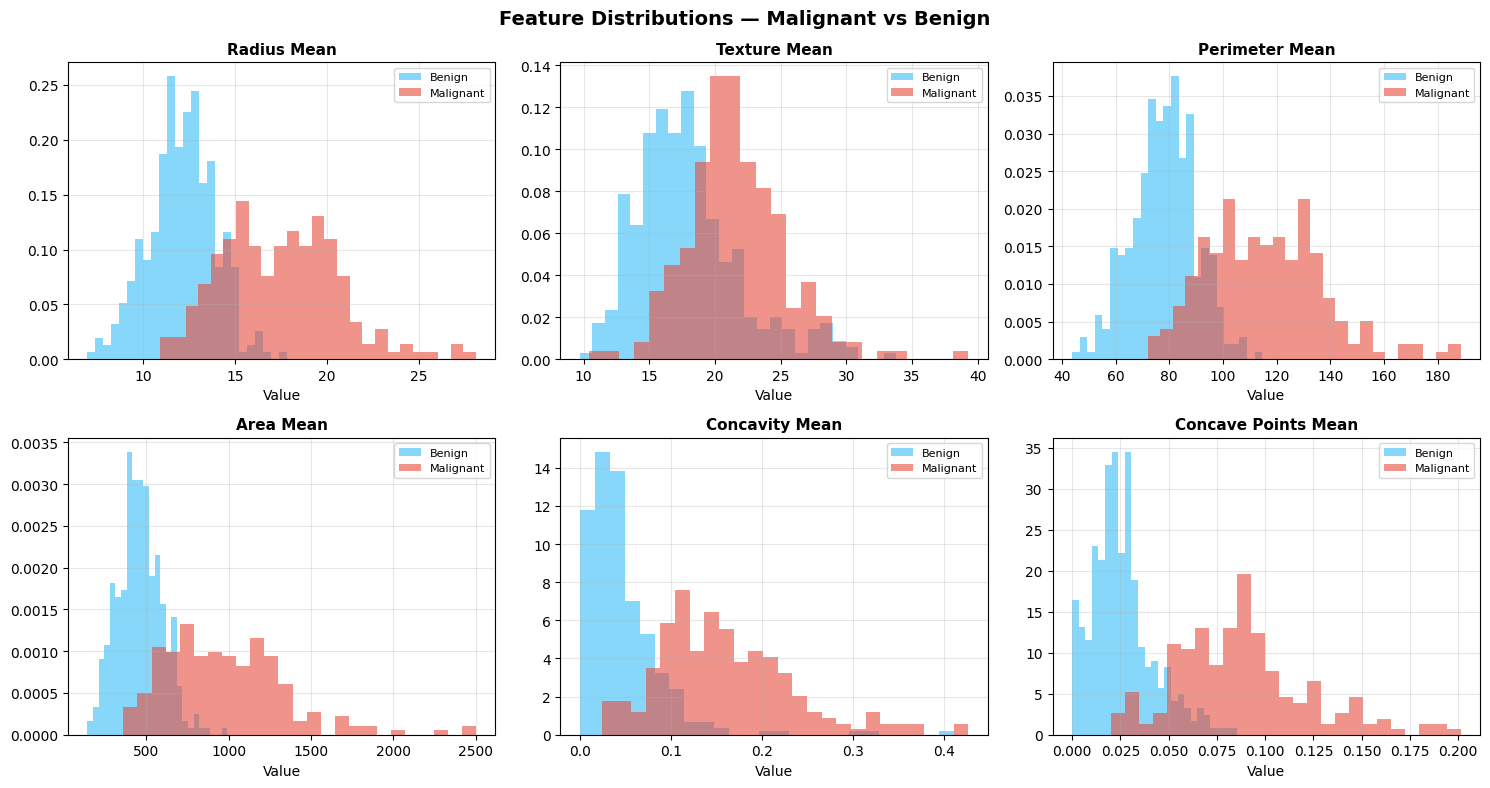

In [3]:
# Distribution of top features by diagnosis
top_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                'concavity_mean', 'concave points_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions — Malignant vs Benign', fontsize=14, fontweight='bold')

for ax, feat in zip(axes.ravel(), top_features):
    for diag, color, label in [('B', '#38bdf8', 'Benign'), ('M', '#e74c3c', 'Malignant')]:
        subset = df[df['diagnosis'] == diag][feat]
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

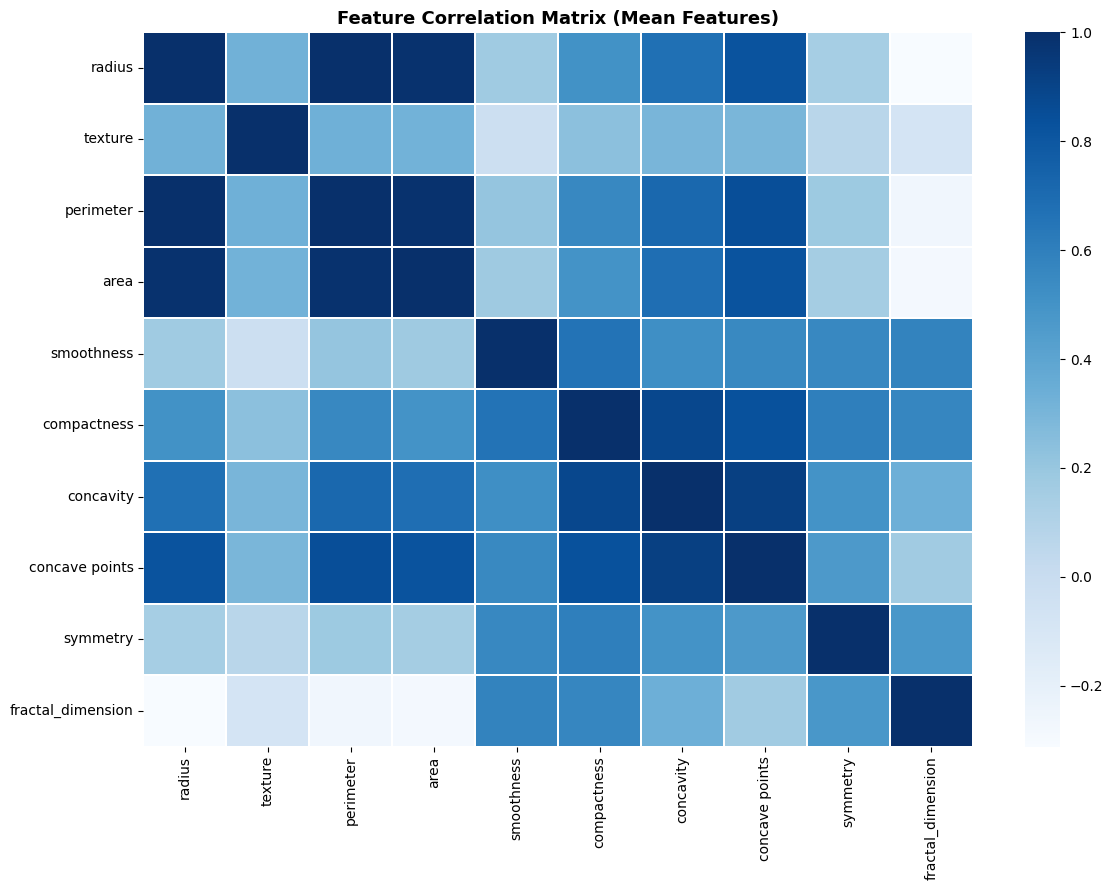

In [4]:
# Correlation heatmap of mean features
mean_cols = [c for c in df.columns if c.endswith('_mean')]
corr = df[mean_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='Blues', annot=False, linewidths=0.3,
            xticklabels=[c.replace('_mean','') for c in mean_cols],
            yticklabels=[c.replace('_mean','') for c in mean_cols])
plt.title('Feature Correlation Matrix (Mean Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<div style="background: #060c1a; border-left: 4px solid #38bdf8; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #7dd3fc;">
  <strong style="color: #e0f2fe;">💡 Observations:</strong> Malignant tumours consistently show larger radius, perimeter, area, and higher concavity — physically, they tend to be larger and more irregularly shaped. Many features are highly correlated (radius, perimeter, area are all size measures), which won't cause issues for KNN but would for linear models.
</div>

<a id='preprocess'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Preprocessing — Why Scaling is Mandatory for KNN</h2>
</div>

KNN is perhaps **the most scale-sensitive algorithm in all of ML**. Distance is computed across all features simultaneously. A feature like `area_mean` (range: 143–2501) will completely dominate `smoothness_mean` (range: 0.05–0.16) in the Euclidean calculation — making `smoothness_mean` invisible to the model.

<div style="background: #060c1a; border: 1px solid #1e2d50; border-radius: 10px; padding: 16px 22px; margin: 14px 0; font-size: 13px;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px;">
    <div>
      <div style="color: #e74c3c; font-weight: 700; margin-bottom: 6px;">❌ Without Scaling</div>
      <div style="color: #7dd3fc;">distance ≈ √(Δarea² + Δsmooth²)<br/>≈ √(200² + 0.01²)<br/>= dominated entirely by area</div>
    </div>
    <div>
      <div style="color: #22c55e; font-weight: 700; margin-bottom: 6px;">✅ After StandardScaler</div>
      <div style="color: #7dd3fc;">All features: mean=0, std=1<br/>distance = √(Δarea_z² + Δsmooth_z²)<br/>each feature contributes equally</div>
    </div>
  </div>
</div>

<div style="background: #060c1a; border: 1px solid #1e2d50; border-radius: 8px; padding: 12px 18px; margin: 12px 0; font-size: 13px; color: #7dd3fc;">
  <strong style="color: #38bdf8;">⚠️ Data leakage warning:</strong> Always fit the scaler on <code>X_train</code> only, then transform both train and test. Fitting on all data would leak test set statistics into training — inflating performance estimates.
</div>

In [5]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"\nSuggested starting K ≈ √{len(X_train)} ≈ {int(np.sqrt(len(X_train)))}")

# Scale — fit on train only!
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\nFeature ranges BEFORE scaling:")
print(f"  area_mean      : [{X_train['area_mean'].min():.1f}, {X_train['area_mean'].max():.1f}]")
print(f"  smoothness_mean: [{X_train['smoothness_mean'].min():.4f}, {X_train['smoothness_mean'].max():.4f}]")
print(f"\nFeature ranges AFTER scaling (z-scores):")
print(f"  area_mean      : [{X_train_s[:,3].min():.2f}, {X_train_s[:,3].max():.2f}]")
print(f"  smoothness_mean: [{X_train_s[:,4].min():.2f}, {X_train_s[:,4].max():.2f}]")

Train size : (426, 30)
Test size  : (143, 30)

Suggested starting K ≈ √426 ≈ 20

Feature ranges BEFORE scaling:
  area_mean      : [143.5, 2501.0]
  smoothness_mean: [0.0526, 0.1634]

Feature ranges AFTER scaling (z-scores):
  area_mean      : [-1.46, 5.35]
  smoothness_mean: [-3.04, 4.77]


<a id='train'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 8</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Training &amp; Evaluation — K = 5</h2>
</div>

We start with K=5 as a reasonable default. In a medical context like cancer detection, **Recall for Malignant is the critical metric** — missing a cancer case (False Negative) is far more dangerous than a false alarm.

In [6]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)

y_pred = knn.predict(X_test_s)

acc = accuracy_score(y_test, y_pred)
print(f"KNN (K=5) Accuracy : {acc:.4f}  ({acc*100:.2f}%)\n")
print(classification_report(y_test, y_pred, target_names=['Benign (B)', 'Malignant (M)']))

KNN (K=5) Accuracy : 0.9720  (97.20%)

               precision    recall  f1-score   support

   Benign (B)       0.96      1.00      0.98        87
Malignant (M)       1.00      0.93      0.96        56

     accuracy                           0.97       143
    macro avg       0.98      0.96      0.97       143
 weighted avg       0.97      0.97      0.97       143



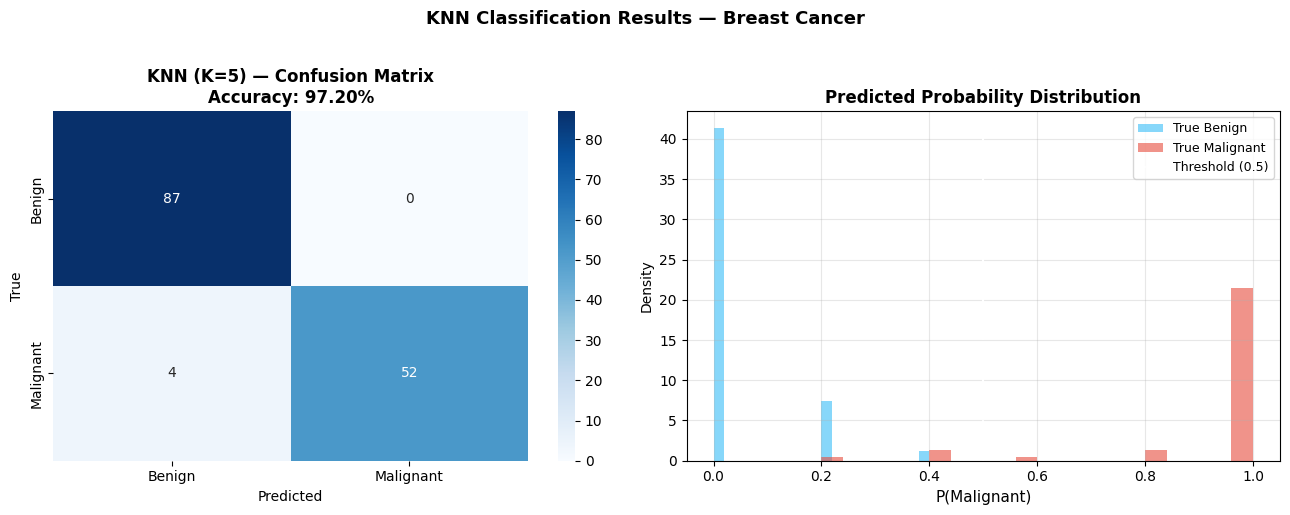

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['B', 'M'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
axes[0].set_title(f'KNN (K=5) — Confusion Matrix\nAccuracy: {acc*100:.2f}%',
                  fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Predicted probability distribution
y_proba = knn.predict_proba(X_test_s)[:, 1]  # P(Malignant)
benign_mask    = (y_test == 'B').values
malignant_mask = (y_test == 'M').values
axes[1].hist(y_proba[benign_mask],    bins=20, alpha=0.6, color='#38bdf8', label='True Benign',    density=True)
axes[1].hist(y_proba[malignant_mask], bins=20, alpha=0.6, color='#e74c3c', label='True Malignant', density=True)
axes[1].axvline(0.5, color='white', linewidth=1.5, linestyle='--', label='Threshold (0.5)')
axes[1].set_xlabel('P(Malignant)', fontsize=11)
axes[1].set_ylabel('Density')
axes[1].set_title('Predicted Probability Distribution', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('KNN Classification Results — Breast Cancer', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='k-sweep'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 9</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Finding the Optimal K — Accuracy vs K Plot</h2>
</div>

We sweep K from 1 to 15 and plot accuracy on both train and test sets. The train-test gap reveals overfitting (small K) vs underfitting (large K). We also add 5-fold cross-validation scores for a more reliable estimate.

In [8]:
k_range  = range(1, 16)
train_scores, test_scores, cv_scores = [], [], []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_s, y_train)

    train_scores.append(accuracy_score(y_train, knn_k.predict(X_train_s)))
    test_scores.append(accuracy_score(y_test,   knn_k.predict(X_test_s)))

    cv = cross_val_score(knn_k, X_train_s, y_train, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())

best_k_test = list(k_range)[np.argmax(test_scores)]
best_k_cv   = list(k_range)[np.argmax(cv_scores)]
print(f"Best K by test accuracy : K={best_k_test}  (acc={max(test_scores):.4f})")
print(f"Best K by CV accuracy   : K={best_k_cv}  (acc={max(cv_scores):.4f})")

Best K by test accuracy : K=3  (acc=0.9860)
Best K by CV accuracy   : K=3  (acc=0.9695)


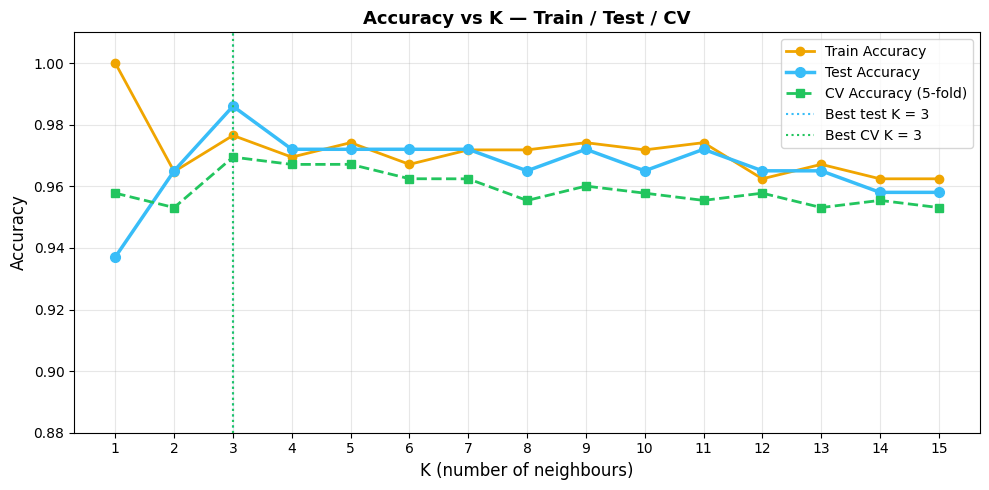

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(k_range, train_scores, 'o-', color='#f0a500', linewidth=2,
         markersize=6, label='Train Accuracy')
plt.plot(k_range, test_scores,  'o-', color='#38bdf8', linewidth=2.5,
         markersize=7, label='Test Accuracy')
plt.plot(k_range, cv_scores,    's--', color='#22c55e', linewidth=2,
         markersize=6, label='CV Accuracy (5-fold)')

plt.axvline(best_k_test, color='#38bdf8', linewidth=1.5, linestyle=':',
            label=f'Best test K = {best_k_test}')
plt.axvline(best_k_cv,   color='#22c55e', linewidth=1.5, linestyle=':',
            label=f'Best CV K = {best_k_cv}')

plt.xticks(list(k_range))
plt.xlabel('K (number of neighbours)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs K — Train / Test / CV', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim(0.88, 1.01)
plt.tight_layout()
plt.show()

<div style="background: #060c1a; border-left: 4px solid #38bdf8; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #7dd3fc;">
  <strong style="color: #e0f2fe;">✅ Reading the plot:</strong> Train accuracy (orange) starts at 100% for K=1 — the model memorises training data perfectly. As K increases, it smooths out and drops. Test accuracy (blue) and CV accuracy (green) peak at an intermediate K — that's your optimal value. Use CV accuracy (green) as your guide since it's more reliable than a single test set evaluation.
</div>

<a id='boundary'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 10</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Decision Boundary Visualisation — Interactive</h2>
</div>

To visualise the boundary we reduce to **2 features** (first 2 principal components of the original data) so we can plot in 2D. The coloured regions show which class KNN would predict at each point in feature space. Notice how the boundary becomes **smoother as K increases** — less jagged = less overfit.

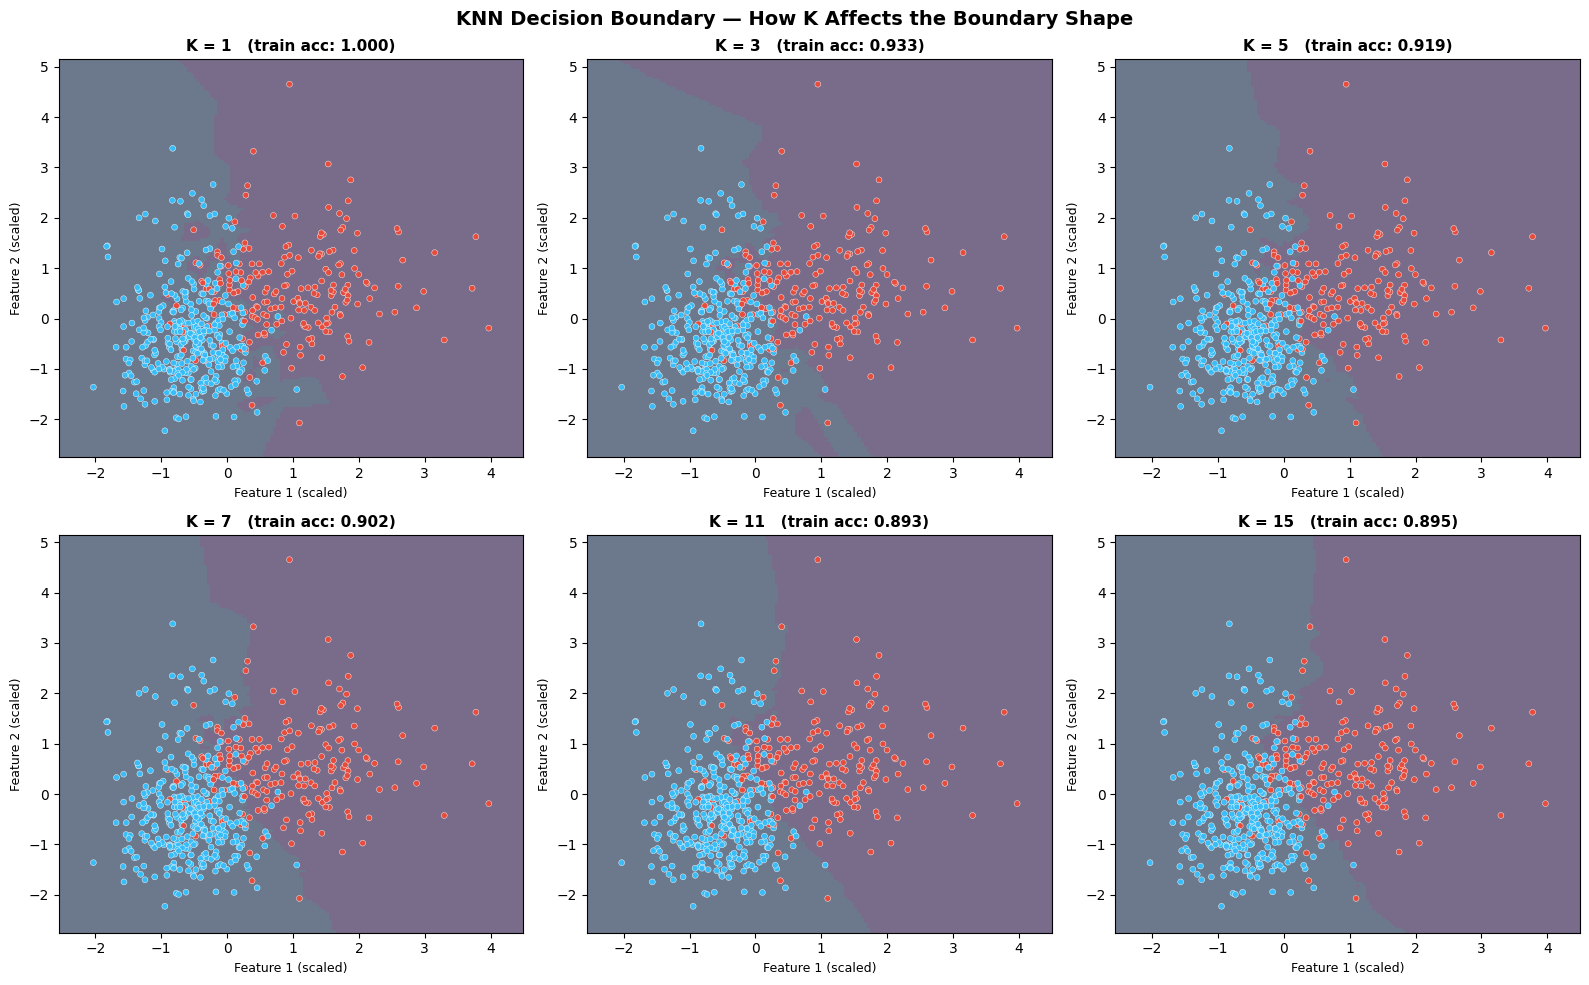

In [10]:
# Use sklearn's built-in breast cancer dataset for 2D boundary (first 2 features)
cancer    = datasets.load_breast_cancer()
X_2d      = StandardScaler().fit_transform(cancer.data[:, :2])  # first 2 features, scaled
y_2d      = cancer.target

cmap_bg   = ListedColormap(['#1e0a3c', '#0a2040'])   # purple=malignant, blue=benign backgrounds
cmap_pts  = ListedColormap(['#e74c3c', '#38bdf8'])   # red=malignant, blue=benign points

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('KNN Decision Boundary — How K Affects the Boundary Shape',
             fontsize=14, fontweight='bold')

for ax, k in zip(axes.ravel(), [1, 3, 5, 7, 11, 15]):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_2d, y_2d)

    x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
    y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                          np.arange(y_min, y_max, 0.05))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.pcolormesh(xx, yy, Z, cmap=cmap_bg, alpha=0.6)
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap=cmap_pts,
               edgecolors='white', linewidth=0.3, s=18, zorder=3)

    acc_k = accuracy_score(y_2d, clf.predict(X_2d))
    ax.set_title(f'K = {k}   (train acc: {acc_k:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1 (scaled)', fontsize=9)
    ax.set_ylabel('Feature 2 (scaled)', fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# Interactive widget — sweep K live
from ipywidgets import interact, fixed

def plot_decision_boundaries(n_neighbors, data, labels):
    cmap_light = ListedColormap(['#1e0a3c', '#0a2040'])
    cmap_bold  = ListedColormap(['#e74c3c', '#38bdf8'])

    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(data, labels)

    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                          np.arange(y_min, y_max, 0.05))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.6)
    plt.scatter(data[:, 0], data[:, 1], c=labels, cmap=cmap_bold,
                edgecolor='white', linewidth=0.3, s=20)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'KNN Decision Boundary  (K = {n_neighbors})', fontsize=13, fontweight='bold')
    plt.xlabel('Feature 1 (scaled)')
    plt.ylabel('Feature 2 (scaled)')
    plt.tight_layout()
    plt.show()

interact(plot_decision_boundaries,
         n_neighbors=(1, 20, 1),
         data=fixed(X_2d),
         labels=fixed(y_2d));

interactive(children=(IntSlider(value=10, description='n_neighbors', max=20, min=1), Output()), _dom_classes=(…

<a id='limits'></a>
<div style="border-bottom: 2px solid #38bdf8; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #38bdf8; color: #0a0a1f; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 11</span>
  <h2 style="color: #e0f2fe; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Limitations of KNN</h2>
</div>

KNN is intuitive and powerful for small-medium datasets, but it has serious weaknesses at scale:

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin: 20px 0;">
  <div style="background: #060c1a; border: 1px solid #1e2d50; border-left: 3px solid #e74c3c; border-radius: 0 8px 8px 0; padding: 16px 18px;">
    <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🐢 Slow Prediction</div>
    <div style="color: #7dd3fc; font-size: 13px; line-height: 1.7;">Every prediction requires computing distance to all n training points. O(n·d) per query — gets painfully slow for large datasets. A dataset with 1M rows and 100 features means 100M multiplications per prediction.</div>
  </div>
  <div style="background: #060c1a; border: 1px solid #1e2d50; border-left: 3px solid #e74c3c; border-radius: 0 8px 8px 0; padding: 16px 18px;">
    <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 6px;">💾 Memory Heavy</div>
    <div style="color: #7dd3fc; font-size: 13px; line-height: 1.7;">The entire training set must be stored in memory. No model compression. Unlike Logistic Regression (30 weights for 30 features), KNN needs all 569 × 30 = 17,070 values.</div>
  </div>
  <div style="background: #060c1a; border: 1px solid #1e2d50; border-left: 3px solid #f0a500; border-radius: 0 8px 8px 0; padding: 16px 18px;">
    <div style="color: #f0a500; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📉 Curse of Dimensionality</div>
    <div style="color: #7dd3fc; font-size: 13px; line-height: 1.7;">In high dimensions, all points become approximately equidistant — "nearest" loses meaning. With 100+ features, distances bunch together and KNN struggles to find meaningful neighbours.</div>
  </div>
  <div style="background: #060c1a; border: 1px solid #1e2d50; border-left: 3px solid #f0a500; border-radius: 0 8px 8px 0; padding: 16px 18px;">
    <div style="color: #f0a500; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚖️ Imbalanced Classes</div>
    <div style="color: #7dd3fc; font-size: 13px; line-height: 1.7;">Majority class dominates voting. With 90% benign and 10% malignant, KNN with large K will rarely predict malignant. Mitigate with weighted voting (<code>weights='distance'</code>) or SMOTE.</div>
  </div>
  <div style="background: #060c1a; border: 1px solid #1e2d50; border-left: 3px solid #f0a500; border-radius: 0 8px 8px 0; padding: 16px 18px;">
    <div style="color: #f0a500; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔧 Feature Scaling Required</div>
    <div style="color: #7dd3fc; font-size: 13px; line-height: 1.7;">Must scale before every KNN application. Adds a preprocessing step and creates data leakage risk if not done correctly (fit on train only).</div>
  </div>
  <div style="background: #060c1a; border: 1px solid #1e2d50; border-left: 3px solid #7dd3fc; border-radius: 0 8px 8px 0; padding: 16px 18px;">
    <div style="color: #7dd3fc; font-weight: 700; font-size: 13px; margin-bottom: 6px;">✅ When KNN Excels</div>
    <div style="color: #7dd3fc; font-size: 13px; line-height: 1.7;">Small to medium datasets. Low to moderate dimensionality. Non-linear boundaries. Quick baseline before complex models. Recommendation systems (similarity-based).</div>
  </div>
</div>

<div style="background: linear-gradient(135deg, #0a0a1f 0%, #0d1a35 100%); border: 1px solid #1e2d50; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Summary &amp; Key Takeaways</h2>
  <p style="color: #7dd3fc; font-size: 13px; margin: 0 0 20px 0;">What to remember about KNN.</p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(56,189,248,0.08); border: 1px solid #1e2d50; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #38bdf8; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📍 Core Idea</div>
      <div style="color: #7dd3fc; font-size: 12px; line-height: 1.7;">Classify by majority vote of K nearest training points. No model parameters — just distances. Non-parametric and non-linear.</div>
    </div>
    <div style="background: rgba(56,189,248,0.08); border: 1px solid #1e2d50; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #38bdf8; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📏 Always Scale</div>
      <div style="color: #7dd3fc; font-size: 12px; line-height: 1.7;">StandardScaler before KNN is non-negotiable. Large-scale features dominate distance computation and silently destroy performance.</div>
    </div>
    <div style="background: rgba(56,189,248,0.08); border: 1px solid #1e2d50; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #38bdf8; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔢 Tuning K</div>
      <div style="color: #7dd3fc; font-size: 12px; line-height: 1.7;">K=1 → overfit (jagged boundary). K=n → underfit. Start at √n, then tune with cross-validation. Prefer odd K for binary classification.</div>
    </div>
    <div style="background: rgba(56,189,248,0.08); border: 1px solid #1e2d50; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #38bdf8; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚡ Best Use Cases</div>
      <div style="color: #7dd3fc; font-size: 12px; line-height: 1.7;">Small/medium datasets with ≤50 features. Good baseline model. Recommender systems. Image recognition with low-dim embeddings.</div>
    </div>
  </div>
  <div style="padding-top: 14px; border-top: 1px solid #1e2d50; color: #7dd3fc; font-size: 12px;">
    Next up → <strong style='color:#38bdf8;'>ML 45: Support Vector Machines (SVM) — Maximum Margin Classifiers</strong>
  </div>
</div>